# Semana 12 - Análisis de Grafos y Reporte de Centralidad

## Posición en el Proyecto

- Anterior: recomendación basada en contenido y matrix factorization SVD (Semanas 10-11)
- Esta semana: los repositorios se convierten en nodos, los topics compartidos se convierten en aristas, la estructura del grafo revela influencia estructural
- Siguiente: PageRank como ranking recursivo del grafo (Semana 14 defensa final)

## Contrato de Aristas — Qué Significa el Grafo

En OSS-Intel, el grafo se define así:

- **Nodo**: un repositorio de GitHub
- **Arista**: dos repositorios comparten al menos un topic en común
- **Peso**: número de topics compartidos entre dos repositorios
- **Direccionalidad**: no dirigido — si el repo A comparte topics con el repo B, la relación es simétrica

La arista significa: **estos repositorios fueron etiquetados con los mismos topics por sus autores.**

NO significa:
- que un repositorio depende del otro
- que los repositorios son funcionalmente idénticos
- que un repositorio causó la creación del otro

Esta distinción es esencial. Toda métrica del grafo hereda el significado de la definición de la arista.

Ejemplo de grafo OSS-Intel:
  Nodos: ['tensorflow', 'pytorch', 'llama', 'whisper', 'scikit']
  Aristas con pesos:
    tensorflow -- pytorch: 3 topics compartidos
    tensorflow -- llama: 2 topics compartidos
    tensorflow -- whisper: 2 topics compartidos
    tensorflow -- scikit: 2 topics compartidos
    pytorch -- llama: 2 topics compartidos
    pytorch -- whisper: 2 topics compartidos
    pytorch -- scikit: 2 topics compartidos
    llama -- whisper: 2 topics compartidos
    llama -- scikit: 1 topics compartidos
    whisper -- scikit: 1 topics compartidos


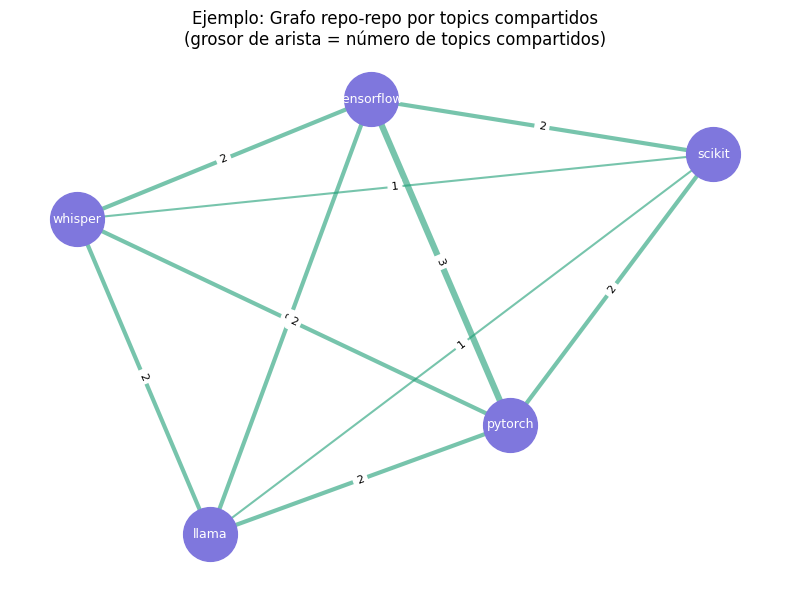

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Ejemplo simple para entender el concepto
# 5 repos con topics compartidos
ejemplo_repos = {
    "tensorflow": ["machine-learning", "python", "deep-learning"],
    "pytorch":    ["machine-learning", "python", "deep-learning"],
    "llama":      ["llm", "python", "deep-learning"],
    "whisper":    ["speech", "python", "deep-learning"],
    "scikit":     ["machine-learning", "python"],
}

# Construir aristas: peso = topics compartidos
aristas_ejemplo = []
repos = list(ejemplo_repos.keys())
for i in range(len(repos)):
    for j in range(i+1, len(repos)):
        topics_i = set(ejemplo_repos[repos[i]])
        topics_j = set(ejemplo_repos[repos[j]])
        peso = len(topics_i & topics_j)
        if peso > 0:
            aristas_ejemplo.append((repos[i], repos[j], peso))

# Construir grafo
G_ejemplo = nx.Graph()
for src, dst, w in aristas_ejemplo:
    G_ejemplo.add_edge(src, dst, weight=w)

print("Ejemplo de grafo OSS-Intel:")
print(f"  Nodos: {list(G_ejemplo.nodes())}")
print(f"  Aristas con pesos:")
for src, dst, data in G_ejemplo.edges(data=True):
    print(f"    {src} -- {dst}: {data['weight']} topics compartidos")

# Visualizar
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_ejemplo, seed=42)
pesos = [G_ejemplo[u][v]["weight"] for u, v in G_ejemplo.edges()]
nx.draw_networkx_nodes(G_ejemplo, pos, node_size=1500, node_color="#7F77DD")
nx.draw_networkx_labels(G_ejemplo, pos, font_size=9, font_color="white")
nx.draw_networkx_edges(G_ejemplo, pos, width=[w*1.5 for w in pesos], alpha=0.6, edge_color="#1D9E75")
nx.draw_networkx_edge_labels(G_ejemplo, pos,
    edge_labels={(u,v): d["weight"] for u,v,d in G_ejemplo.edges(data=True)},
    font_size=8)
plt.title("Ejemplo: Grafo repo-repo por topics compartidos\n(grosor de arista = número de topics compartidos)")
plt.axis("off")
plt.tight_layout()
plt.show()

### Sección 1: Construcción del Grafo Real

El ejemplo anterior mostró el concepto con 5 repos. Ahora construimos el grafo real 
con los 3034 repositorios del dataset.

El proceso es:
1. Cargar repos_clean.csv con los topics de cada repositorio
2. Para cada par de repositorios, calcular cuántos topics comparten
3. Si comparten al menos 1 topic, crear una arista con ese peso
4. Filtrar las aristas más fuertes para mantener el grafo manejable

**Decisión de filtrado**: Nosotros mantendremos las aristas con peso >= 2 (al menos 2 topics compartidos). Esto elimina conexiones débiles basadas en un solo topic genérico como "python" y conserva 
relaciones temáticas más significativas.

In [4]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import ast
from pathlib import Path
from collections import defaultdict

# Cargar dataset
DATA_PATH = Path("../data/processed/repos_clean.csv")
df = pd.read_csv(DATA_PATH)
df["topics_list"] = df["topics"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

print(f"Dataset cargado: {df.shape}")
print(f"Repos con topics: {(df['num_topics'] > 0).sum()}")
print(f"Repos sin topics: {(df['num_topics'] == 0).sum()}")

# Construir lista de aristas
# Para cada par de repos, contar topics compartidos
print("\nConstruyendo aristas...")

edges = []
repos_idx = df.index.tolist()
topics_por_repo = {i: set(df.loc[i, "topics_list"]) for i in repos_idx}

for i in range(len(repos_idx)):
    for j in range(i+1, len(repos_idx)):
        idx_i = repos_idx[i]
        idx_j = repos_idx[j]
        peso = len(topics_por_repo[idx_i] & topics_por_repo[idx_j])
        if peso >= 2:  # filtro: al menos 2 topics compartidos
            edges.append((idx_i, idx_j, peso))

print(f"Aristas encontradas (peso >= 2): {len(edges)}")

# Construir grafo
G = nx.Graph()
for i in repos_idx:
    G.add_node(i, nombre=df.loc[i, "nombre"], stars=df.loc[i, "stars"])

for src, dst, w in edges:
    G.add_edge(src, dst, weight=w)

print(f"\nGrafo construido:")
print(f"  Nodos: {G.number_of_nodes()}")
print(f"  Aristas: {G.number_of_edges()}")
print(f"  Densidad: {nx.density(G):.6f}")
print(f"  Self-loops: {nx.number_of_selfloops(G)}")

Dataset cargado: (3034, 16)
Repos con topics: 3034
Repos sin topics: 0

Construyendo aristas...
Aristas encontradas (peso >= 2): 362471

Grafo construido:
  Nodos: 3034
  Aristas: 362471
  Densidad: 0.078780
  Self-loops: 0


#### Decisión de filtrado ajustada

El grafo inicial con peso >= 2 generó 362,471 aristas y densidad de 0.079. 
Demasiado denso para análisis estructural significativo. En grafos muy densos 
todos los nodos están conectados con todos y las métricas de centralidad 
pierden discriminación.

In [5]:
# Filtrar aristas más fuertes
MIN_WEIGHT = 4

edges_filtradas = [(src, dst, w) for src, dst, w in edges if w >= MIN_WEIGHT]
print(f"Aristas con peso >= {MIN_WEIGHT}: {len(edges_filtradas)}")

# Reconstruir grafo filtrado
G = nx.Graph()
for i in repos_idx:
    G.add_node(i, nombre=df.loc[i, "nombre"], stars=df.loc[i, "stars"])

for src, dst, w in edges_filtradas:
    G.add_edge(src, dst, weight=w)

# Eliminar nodos aislados
nodos_aislados = [n for n in G.nodes() if G.degree(n) == 0]
G.remove_nodes_from(nodos_aislados)

print(f"\nGrafo filtrado:")
print(f"  Nodos: {G.number_of_nodes()}")
print(f"  Aristas: {G.number_of_edges()}")
print(f"  Densidad: {nx.density(G):.6f}")
print(f"  Nodos aislados eliminados: {len(nodos_aislados)}")

Aristas con peso >= 4: 24839

Grafo filtrado:
  Nodos: 1938
  Aristas: 24839
  Densidad: 0.013234
  Nodos aislados eliminados: 1096


#### Interpretación del grafo filtrado

Con peso >= 4 el grafo tiene 1938 nodos, 24839 aristas y densidad de 0.013.

**¿Qué significa la densidad 0.013?**

La densidad mide qué fracción de todas las aristas posibles realmente existen.
Un grafo completamente conectado (todos con todos) tiene densidad 1.0.
Un grafo sin ninguna conexión tiene densidad 0.0.

Densidad = aristas existentes / aristas posibles
Densidad = 24,839 / (1938 × 1937 / 2) = 0.013

Esto significa que solo el 1.3% de todas las conexiones posibles entre 
repositorios existen con al menos 4 topics compartidos. Es un grafo disperso 
— como en la mayoría de redes reales donde no todos se conectan con todos.

**1096 nodos aislados eliminados**: estos son repositorios que no comparten 
4 o más topics con ningún otro repositorio. Son repos muy específicos o con 
pocos topics declarados que quedan fuera del análisis estructural.

**Decisión justificada**: trabajar sobre los 1938 repos conectados es válido 
porque representan el núcleo temático del ecosistema de IA donde las 
relaciones estructurales son significativas.

### Sección 2: Componentes Conectados, Degree y Weighted Degree

Un componente conectado es un grupo de nodos que pueden alcanzarse entre sí 
mediante caminos en el grafo. Si el grafo tiene múltiples componentes, 
un random walk no puede saltar entre ellos, queda atrapado en su componente.

Analizamos tres métricas locales:

- **Degree no ponderado**: cuántos repos vecinos directos tiene un repo
- **Weighted degree**: suma de los pesos de todas sus aristas, cuánta 
  co-ocurrencia temática acumula
- **Componentes**: cuántos grupos aislados existen y qué tan grande es cada uno

In [6]:
# ============================================================
# Sección 2 — Componentes, Degree y Weighted Degree
# ============================================================

# Componentes conectados
componentes = list(nx.connected_components(G))
componentes_sorted = sorted(componentes, key=len, reverse=True)

print(f"Número de componentes: {len(componentes)}")
print(f"\nTop 5 componentes por tamaño:")
for i, comp in enumerate(componentes_sorted[:5]):
    print(f"  Componente {i+1}: {len(comp)} nodos")

# Trabajar sobre el componente más grande
componente_principal = componentes_sorted[0]
G_main = G.subgraph(componente_principal).copy()
print(f"\nComponente principal:")
print(f"  Nodos: {G_main.number_of_nodes()}")
print(f"  Aristas: {G_main.number_of_edges()}")
print(f"  Densidad: {nx.density(G_main):.6f}")

# Degree no ponderado
degree_dict = dict(G_main.degree())

# Weighted degree
weighted_degree_dict = dict(G_main.degree(weight="weight"))

# Construir tabla comparativa
degree_df = pd.DataFrame({
    "repo_idx": list(degree_dict.keys()),
    "degree": list(degree_dict.values()),
    "weighted_degree": [weighted_degree_dict[n] for n in degree_dict.keys()]
})
degree_df["nombre"] = degree_df["repo_idx"].map(df["nombre"])
degree_df["stars"] = degree_df["repo_idx"].map(df["stars"])
degree_df = degree_df.sort_values("weighted_degree", ascending=False).reset_index(drop=True)

print(f"\nTop 10 por weighted degree:")
print(degree_df[["nombre", "degree", "weighted_degree", "stars"]].head(10).to_string(index=False))

print(f"\nTop 10 por degree no ponderado:")
print(degree_df.sort_values("degree", ascending=False)[
    ["nombre", "degree", "weighted_degree", "stars"]
].head(10).to_string(index=False))

Número de componentes: 34

Top 5 componentes por tamaño:
  Componente 1: 1861 nodos
  Componente 2: 5 nodos
  Componente 3: 3 nodos
  Componente 4: 3 nodos
  Componente 5: 3 nodos

Componente principal:
  Nodos: 1861
  Aristas: 24787
  Densidad: 0.014322

Top 10 por weighted degree:
                        nombre  degree  weighted_degree  stars
                 d2l-ai/d2l-en     280             1331  28729
       rasbt/LLMs-from-scratch     289             1327  91729
bharathgs/Awesome-pytorch-list     277             1269  16486
               explosion/thinc     267             1214   2891
          huggingface/datasets     265             1198  21469
 lukasmasuch/best-of-ml-python     253             1195  23453
             tangyudi/Ai-Learn     249             1180  12946
         tensorzero/tensorzero     250             1176  11289
          roboflow/supervision     243             1090  38259
               explosion/spaCy     234             1076  33528

Top 10 por degree no p

#### Interpretación — Componentes y Degree

**Componentes**: el grafo tiene 34 componentes. El componente principal tiene 
1861 nodos, el 96% de los repos conectados. Los 33 componentes restantes 
tienen entre 3 y 5 nodos cada uno, son grupos muy pequeños de repos con 
topics muy específicos que no conectan con el ecosistema principal.

Todo el análisis siguiente se realiza sobre el componente principal de 1861 nodos.

**Degree vs Weighted Degree**:

El degree no ponderado cuenta cuántos repos vecinos tiene cada repo.
El weighted degree suma los pesos de todas las aristas, mide la fuerza 
total de co-ocurrencia temática.

En este caso ambas listas son casi idénticas, los repos con más vecinos 
también tienen más fuerza acumulada. Esto indica que en el ecosistema de IA 
los repos más conectados usan topics variados y frecuentes.

**Observación importante**: `d2l-ai/d2l-en` tiene el mayor weighted degree 
(1331) pero no el mayor degree (280 vs 289 de LLMs-from-scratch). Esto 
significa que d2l-en tiene aristas más fuertes en promedio, comparte más 
topics por conexión. `explosion/thinc` con solo 2891 stars tiene weighted 
degree de 1214, más conectado estructuralmente que repos con 10 veces más 
stars. Eso es exactamente lo que el grafo revela que la popularidad no revela.

In [7]:
# ============================================================
# Validity check — sensibilidad al umbral de filtrado
# El profesor exige mostrar cómo cambia el grafo con distintos umbrales
# ============================================================

print("Sensibilidad al umbral de peso:")
print(f"{'Umbral':>8} | {'Aristas':>8} | {'Nodos':>6} | {'Componentes':>12} | {'Densidad':>10}")
print("-" * 55)

for umbral in [2, 3, 4, 5, 6, 8]:
    edges_u = [(s, d, w) for s, d, w in edges if w >= umbral]
    G_u = nx.Graph()
    G_u.add_nodes_from(repos_idx)
    for s, d, w in edges_u:
        G_u.add_edge(s, d, weight=w)
    nodos_u = [n for n in G_u.nodes() if G_u.degree(n) > 0]
    G_u = G_u.subgraph(nodos_u)
    comps_u = nx.number_connected_components(G_u)
    print(f"{umbral:>8} | {len(edges_u):>8} | {G_u.number_of_nodes():>6} | {comps_u:>12} | {nx.density(G_u):>10.6f}")

Sensibilidad al umbral de peso:
  Umbral |  Aristas |  Nodos |  Componentes |   Densidad
-------------------------------------------------------
       2 |   362471 |   2969 |            2 |   0.082268
       3 |    94055 |   2582 |           12 |   0.028227
       4 |    24839 |   1938 |           34 |   0.013234
       5 |     6739 |   1263 |           68 |   0.008456
       6 |     1973 |    770 |           77 |   0.006664
       8 |      267 |    265 |           69 |   0.007633


#### Interpretación: Sensibilidad al Umbral de Filtrado
"Umbral = 2,
Se conectan si comparten 2 o más topics."

Conforme aumentamos el umbral exigiendo más topics compartidos para crear 
una arista, el grafo se va fragmentando:

- **Umbral 2**: 362,471 aristas, casi todo conectado en 2 componentes. 
  Demasiado denso, topics genéricos como python conectan todo con todo.
- **Umbral 4**: 24,839 aristas, 34 componentes. Nuestro umbral elegido, 
  balance entre conectividad y significado temático real.
- **Umbral 6**: solo 1,973 aristas, 77 componentes. El grafo se fragmenta mucho.
- **Umbral 8**: 267 aristas, el grafo casi desaparece.

**Observación importante**: en umbral 8 la densidad sube ligeramente respecto 
a umbral 6. Esto significa que los pocos repos que comparten 8 o más topics 
forman un grupo muy denso entre ellos, son repos altamente especializados 
en el mismo nicho temático.

**Justificación del umbral 4**: es el punto donde el componente principal 
sigue siendo grande (1861 nodos) pero las conexiones son temáticamente 
significativas, no basadas en topics genéricos como python o deep-learning 
que conectarían repos de dominios completamente distintos.

El filtrado es una decisión de modelado, no solo limpieza. Cambia la 
topología del grafo y por tanto el significado de todas las métricas 
calculadas sobre él.

### Sección 3: Matrices A, D y P

Para analizar el grafo matemáticamente construimos tres matrices:

**Matriz de adyacencia A**: tabla de nodos x nodos donde A[i][j] = peso 
de la arista entre repo i y repo j. Si no hay arista, A[i][j] = 0.
Como el grafo es no dirigido, A es simétrica: A[i][j] = A[j][i].

**Matriz de grado D**: matriz diagonal donde D[i][i] = weighted degree 
del nodo i. Todos los demás valores son 0.

**Matriz de transición P = D⁻¹ × A**: normaliza cada fila de A dividiendo 
por el weighted degree del nodo. P[i][j] es la probabilidad de moverse 
del repo i al repo j en un paso de random walk.

P es row-stochastic: cada fila suma exactamente 1.0 — es una distribución 
de probabilidad válida sobre los vecinos.

Trabajamos sobre una submuestra del componente principal para que las 
matrices sean manejables en memoria.

In [8]:
# ============================================================
# Sección 3 — Matrices A, D y P
# Trabajamos sobre submuestra de 200 nodos del componente principal
# para mantener las matrices manejables
# ============================================================

import scipy.sparse as sp

# Tomar los 200 nodos con mayor weighted degree
top_nodos = degree_df.head(200)["repo_idx"].tolist()
G_sub = G_main.subgraph(top_nodos).copy()

print(f"Subgrafo para matrices:")
print(f"  Nodos: {G_sub.number_of_nodes()}")
print(f"  Aristas: {G_sub.number_of_edges()}")

# Mapear nodos a indices 0..n
nodos_list = list(G_sub.nodes())
nodo_a_idx = {n: i for i, n in enumerate(nodos_list)}
n = len(nodos_list)

# Construir matriz de adyacencia A (numpy)
A = np.zeros((n, n))
for u, v, data in G_sub.edges(data=True):
    i = nodo_a_idx[u]
    j = nodo_a_idx[v]
    A[i, j] = data["weight"]
    A[j, i] = data["weight"]  # simetrica

print(f"\nMatriz A shape: {A.shape}")
print(f"A es simetrica: {np.allclose(A, A.T)}")
print(f"Self-loops en A: {np.sum(np.diag(A) != 0)}")

# Construir matriz de grado D
d = A.sum(axis=1)  # weighted degree de cada nodo
D = np.diag(d)

print(f"\nMatriz D shape: {D.shape}")
print(f"Weighted degrees min/max: {d.min():.0f} / {d.max():.0f}")

# Construir matriz de transicion P = D^-1 @ A
D_inv = np.diag(1.0 / np.where(d > 0, d, 1.0))
P = D_inv @ A

print(f"\nMatriz P shape: {P.shape}")

# Verificar que P es row-stochastic
row_sums = P.sum(axis=1)
print(f"Filas de P suman 1.0: {np.allclose(row_sums, 1.0)}")
print(f"Suma minima de fila: {row_sums.min():.6f}")
print(f"Suma maxima de fila: {row_sums.max():.6f}")

# Mostrar submatriz 5x5 como ejemplo
nombres_sub = [df.loc[n, "nombre"].split("/")[1] for n in nodos_list[:5]]
print(f"\nSubmatriz A[0:5, 0:5]:")
print(pd.DataFrame(A[:5,:5], index=nombres_sub, columns=nombres_sub).round(0))
print(f"\nSubmatriz P[0:5, 0:5]:")
print(pd.DataFrame(P[:5,:5], index=nombres_sub, columns=nombres_sub).round(4))

Subgrafo para matrices:
  Nodos: 200
  Aristas: 7342

Matriz A shape: (200, 200)
A es simetrica: True
Self-loops en A: 0

Matriz D shape: (200, 200)
Weighted degrees min/max: 116 / 776

Matriz P shape: (200, 200)
Filas de P suman 1.0: True
Suma minima de fila: 1.000000
Suma maxima de fila: 1.000000

Submatriz A[0:5, 0:5]:
                   TensorFlow-World  prompts.chat  transformers  tensorflow  \
TensorFlow-World                0.0           0.0           0.0         5.0   
prompts.chat                    0.0           0.0           0.0         0.0   
transformers                    0.0           0.0           0.0         0.0   
tensorflow                      5.0           0.0           0.0         0.0   
LLMs-from-scratch               0.0           6.0           5.0         0.0   

                   LLMs-from-scratch  
TensorFlow-World                 0.0  
prompts.chat                     6.0  
transformers                     5.0  
tensorflow                       0.0  
LLMs-f